# Image Compression Using Singular Value Decomposition
---
Singular value decomposition (SVD) is an algorithm used to approximate and compress data in large matrices. While it can be used to condense large data sets, its most applicable use is for image compression.

Full SVD:  $ A = U \Sigma V^T $ </br>
Condensed SVD: $ A = \hat{U} \hat{\Sigma} \hat{V^T}$

#### Step 1:
Read the picture “moon.tif” in MATLAB and display it. You may need the “Image
Processing Toolbox” to load this picture. Do your own research to find out how to
read and display images in MATLAB. Attach the original picture in the report

#### Step 2:
Examine the data structure of the stored image. What is the data type of the
matrix that represents the image? Explore different data types of images stored in
MATLAB and present your findings.

##### Step 3:
Now that you have a matrix with intensity values representing the image “moon.tif”,
can you perform SVD on this matrix using svd in MATLAB? Explain your findings.

##### Step 4:
Based on what you found in part 3, perform SVD on the matrix and store the
matrices U , Σ, and V . It is up to you whether you want to do a full SVD or a
condensed SVD.

##### Step 5:
Now we would like to use SVD for image compression using the idea of low-rank
approximation. Write out the mathematical expression of the low-rank approxima-
tion.

##### Step 6: 
Compress the image using four different ranks (your choice). Examine which ranks
are sufficient to identify “enough” details by observation. Discuss your findings and
attach all four compressed pictures in the report.

#### Step 7:
The quality of each rank-k approximation can be quantified using the Peak Signal-
to-Noise Ratio (PSNR), which uses the Root Mean Square Error (RMSE):

{equation here eventually...}

Here, max range denotes the maximum allowed range of pixel values. Compute the
PSNR (or quality) of each of the rank-k approximations you performed in step 6. List
them in a table and discuss your findings

#### Step 8:
One measure of the accuracy of the truncated or rank-k SVD is known as the
explained variance, given by v(k) = ||Ak||F /||A||F , where F denotes the Frobenius
norm. The explained variance does exactly what you would expect: it quantifies
how much of the variance in the data is explained by Ak. Make a plot of v(k) vs.
k for your image. Attach the plot in the report and discuss your findings

#### Step 9:
Read the color picture “saturn.jpg” in MATLAB and perform image compression
using SVD for each channel. Attach the original picture and four compressed pic-
tures in the report. Discuss your methodology and findings using the techniques
you learned in steps 1-8.

In [44]:
%matplotlib inline
import cv2 # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

# define the image that is being processed
img = 'flowers.jpeg'
img_data = cv2.imread(img)

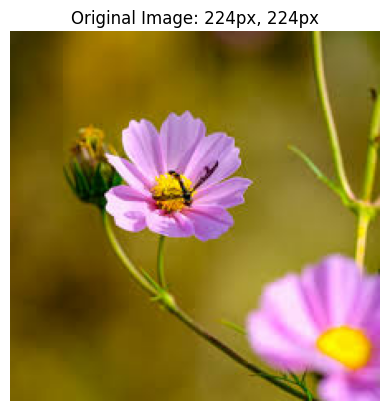

In [45]:
# Return the current image
def show_image(image, title:str):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

res = img_data.shape
show_image(img_data, f"Original Image: {res[0]}px, {res[1]}px")

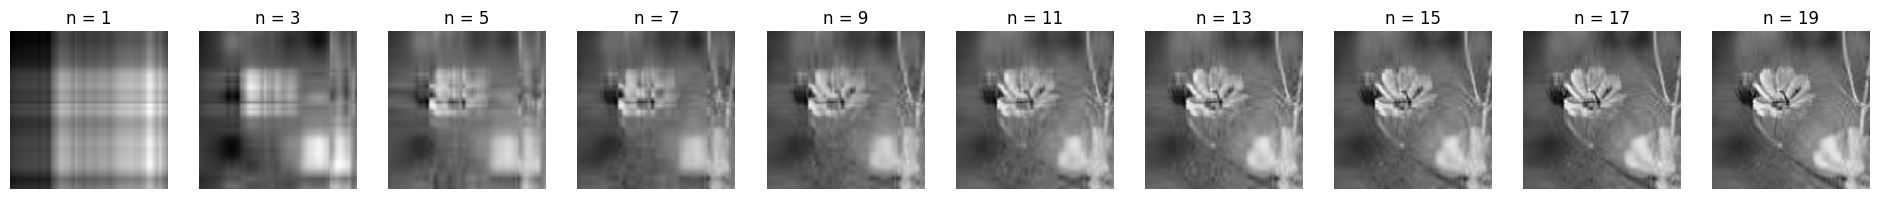

In [46]:
# for grayscale images / output
def svd_gs(image, sv):
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    gs_img = np.matrix(U[:,:sv]) * np.diag(S[:sv]) * np.matrix(Vt[:sv,:])
    return gs_img

# showing the effect after adding 5 more singular values each frame
plt.figure(figsize=(24,4))
start, end, step = 1, 20, 2

for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    img_gs = svd_gs(img, i) # does the svd compression
    plt.imshow(img_gs, cmap='grey')
    plt.title('n = %s' % i)
    plt.axis('off')

plt.show()

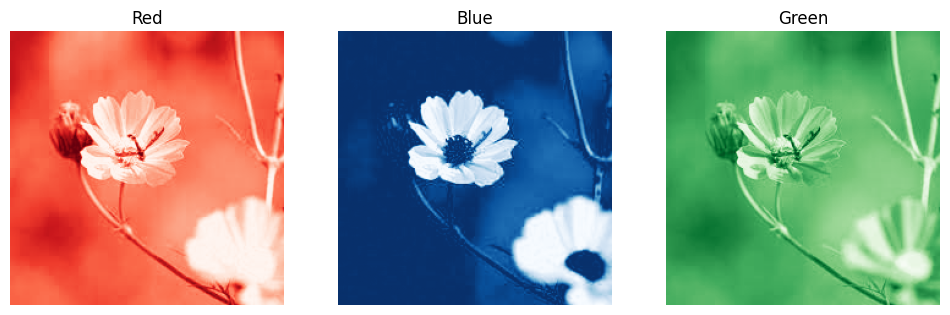

In [ ]:
B, G, R = cv2.split(img_data) # splitting color channels

colors = ['Red', 'Blue', 'Green']
matrices = [R, B, G]

plt.figure(figsize=(12, 4))
for i in range(len((colors))):
    plt.subplot(1, 3, i+1)
    plt.title(colors[i])
    plt.imshow(matrices[i],cmap=f'{colors[i]}s_r')
    plt.axis('off')
plt.show()

In [48]:
# Getting the singular values of the matrix S

sing_val_ex = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)

np.set_printoptions(precision=1)  # 3 decimal places
print("Values of S:")
print(S)

Values of S:
[2.7e+04 5.2e+03 2.9e+03 1.9e+03 1.6e+03 1.6e+03 1.1e+03 1.1e+03 1.0e+03
 9.8e+02 8.7e+02 8.6e+02 7.4e+02 7.2e+02 7.0e+02 6.3e+02 6.1e+02 5.9e+02
 5.3e+02 5.2e+02 5.0e+02 4.7e+02 4.5e+02 4.4e+02 4.2e+02 4.0e+02 3.9e+02
 3.7e+02 3.6e+02 3.6e+02 3.3e+02 3.3e+02 3.2e+02 3.1e+02 3.0e+02 2.9e+02
 2.9e+02 2.8e+02 2.7e+02 2.6e+02 2.5e+02 2.4e+02 2.4e+02 2.3e+02 2.2e+02
 2.2e+02 2.0e+02 2.0e+02 1.9e+02 1.9e+02 1.8e+02 1.8e+02 1.7e+02 1.7e+02
 1.6e+02 1.6e+02 1.5e+02 1.5e+02 1.4e+02 1.4e+02 1.4e+02 1.3e+02 1.3e+02
 1.3e+02 1.2e+02 1.2e+02 1.1e+02 1.1e+02 1.1e+02 1.0e+02 1.0e+02 9.8e+01
 9.6e+01 9.2e+01 9.1e+01 8.6e+01 8.4e+01 8.3e+01 8.1e+01 7.5e+01 7.4e+01
 7.2e+01 7.1e+01 6.9e+01 6.7e+01 6.5e+01 6.2e+01 6.0e+01 5.8e+01 5.7e+01
 5.4e+01 5.3e+01 5.2e+01 5.1e+01 4.9e+01 4.7e+01 4.6e+01 4.4e+01 4.4e+01
 4.3e+01 4.2e+01 3.9e+01 3.8e+01 3.7e+01 3.5e+01 3.4e+01 3.3e+01 3.2e+01
 3.1e+01 3.0e+01 2.9e+01 2.8e+01 2.7e+01 2.6e+01 2.5e+01 2.5e+01 2.3e+01
 2.2e+01 2.2e+01 2.1e+01 2.1e+01 2.0e+

In [49]:
%%time
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=True)

CPU times: user 409 ms, sys: 0 ns, total: 409 ms
Wall time: 27.6 ms


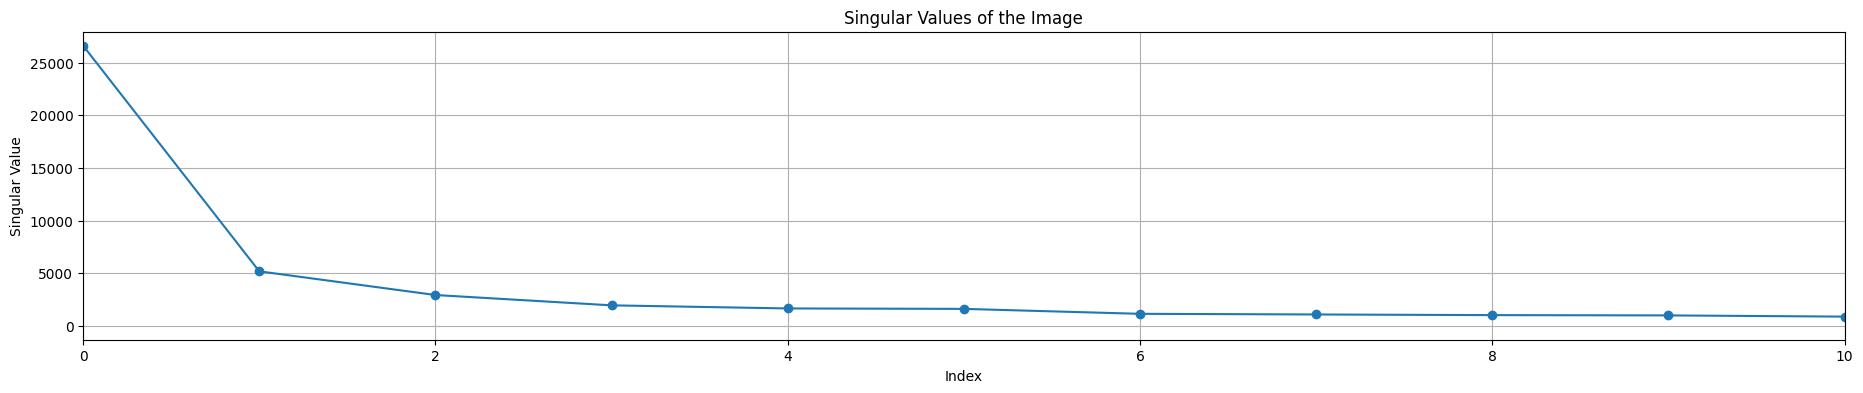

In [50]:
plt.figure(figsize=(50,4))
plt.subplot(1, 2, 1)
plt.plot(S, marker='o')
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.xlim(0, 10) 
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

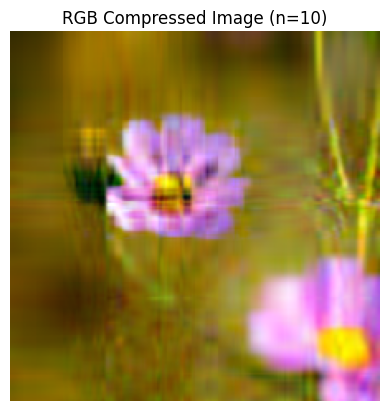

Framework 16: AMD Ryzen 7 7480HS
CPU times: user 1.65 s, sys: 3.99 ms, total: 1.65 s
Wall time: 118 ms


In [51]:
%%time
def svd_color(image, sv):
    B, G, R = cv2.split(image)

    U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)
    U_g, S_g, Vt_g = np.linalg.svd(G, full_matrices=False)
    U_r, S_r, Vt_r = np.linalg.svd(R, full_matrices=False)

    R_comp = np.matrix(U_r[:, :sv]) * np.diag(S_r[:sv]) * np.matrix(Vt_r[:sv, :])
    G_comp = np.matrix(U_g[:, :sv]) * np.diag(S_g[:sv]) * np.matrix(Vt_g[:sv, :])
    B_comp = np.matrix(U_b[:, :sv]) * np.diag(S_b[:sv]) * np.matrix(Vt_b[:sv, :])

    comp_full = cv2.merge([np.clip(R_comp, 1, 255), np.clip(G_comp, 1, 255), np.clip(B_comp, 1, 255)])
    comp_full = comp_full.astype(np.uint8)

    plt.imshow(comp_full)
    plt.title(f'RGB Compressed Image (n={sv})')
    plt.axis('off')
    plt.show()

svd_color(img_data, 10)
print('Framework 16: AMD Ryzen 7 7480HS')